In [1]:
import xarray as xr
import numpy as np
import colormaps as cmaps

In [2]:
import xarray as xr
import numpy as np
import xarray as xr
from pathlib import Path

BASE_PATH = Path("/projects/prjs2023/chapter3/lpjml_output/2026_04_23_global_droughtexp_10years")

def load_all_runs(file_name, var_name):
    paths = {
        "baseline": BASE_PATH / "baseline/output" / f"{file_name}.nc",
        "MM": BASE_PATH / "MM/output" / f"{file_name}.nc",
        "DM": BASE_PATH / "DM/output" / f"{file_name}.nc",
    }
    
    data = {
        key: xr.open_dataset(path)[var_name]
        for key, path in paths.items()
    }
    
    return data
fpc = load_all_runs("fpc", "FPC")
# process function: skip total PFT (first), spatial mean
def process_fpc_per_pft(data):
    data['pft'] = data['pft'] - 2
    return data.sel(pft=slice(0, 7)).convert_calendar("standard").sel(time=slice("1970", "1979"))

# process all scenarios
fpc_proc = {name: process_fpc_per_pft(ds) for name, ds in fpc.items()}

In [3]:
tau_baseline = xr.open_dataset("/home/druijsch/scripts/2026_06_10_efolding_weighted/tau_baseline.nc").FPC
tau_DM = xr.open_dataset("/home/druijsch/scripts/2026_06_10_efolding_weighted/tau_DM.nc").FPC
tau_baseline

<xarray.DataArray 'FPC' (pft: 8, lat: 1397, lon: 3600)> Size: 322MB
[40233600 values with dtype=float64]
Coordinates:
  * pft      (pft) int32 32B 0 1 2 3 4 5 6 7
  * lat      (lat) float64 11kB -55.95 -55.85 -55.75 ... 83.45 83.55 83.65
  * lon      (lon) float64 29kB -179.9 -179.8 -179.8 ... 179.8 179.9 180.0
Attributes:
    standard_name:  FPC
    long_name:      foliage projected cover

In [4]:
FPC0_baseline = (
    fpc_proc["baseline"]
    .isel(time=0)
)

FPC0_DM = (
    fpc_proc["DM"]
    .isel(time=0)
)

In [5]:
weights_baseline = FPC0_baseline / FPC0_baseline.sum("pft")
weights_DM = FPC0_DM / FPC0_DM.sum("pft")
weights_baseline

<xarray.DataArray 'FPC' (pft: 8, lat: 1397, lon: 3600)> Size: 161MB
array([[[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
...
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]]],
      shape=(8, 1397, 3600), dtype=float32)
Coordinates:
  * pft      (pft) int32 32B 0 1 2 3 4 5 6 7
  * lat      (lat) float64 11kB -55.95 -55.85 -55.75 ... 83.45 83.55 83.65
  * lon      (lon) float64 29kB -179.9 -179.8 -179.8 ... 179.8 179.9 180.0
    time     datetime64[ns] 8B 1970-01-16
Attributes:
    standard_name:  FPC
    long_name:      foliage projected cover

In [6]:
total_FPC0_base = FPC0_baseline.sum("pft")
valid_base = total_FPC0_base > 1e-3 

total_FPC0_DM = FPC0_DM.sum("pft")
valid_DM = total_FPC0_DM > 1e-3

In [7]:
tau_weighted_baseline_sum = (tau_baseline * weights_baseline).sum("pft").where(valid_base)
tau_weighted_DM_sum = (tau_DM * weights_DM).sum("pft").where(valid_DM)

tau_weighted_baseline_sum

<xarray.DataArray 'FPC' (lat: 1397, lon: 3600)> Size: 40MB
array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]], shape=(1397, 3600))
Coordinates:
  * lat      (lat) float64 11kB -55.95 -55.85 -55.75 ... 83.45 83.55 83.65
  * lon      (lon) float64 29kB -179.9 -179.8 -179.8 ... 179.8 179.9 180.0
    time     datetime64[ns] 8B 1970-01-16
Attributes:
    standard_name:  FPC
    long_name:      foliage projected cover

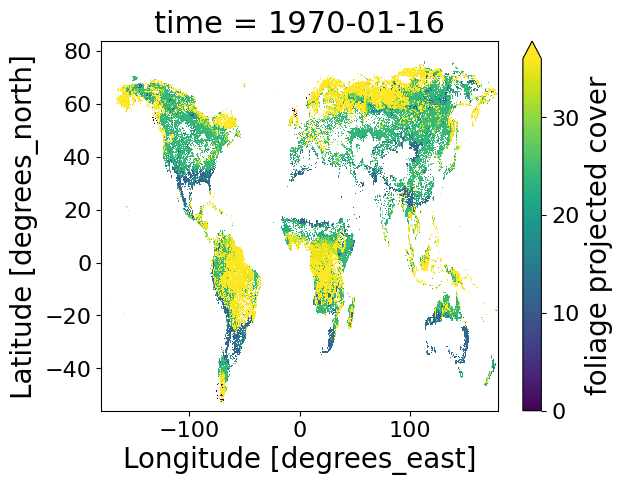

In [83]:
tau_weighted_baseline_sum.plot(vmin = 0, vmax = 36)

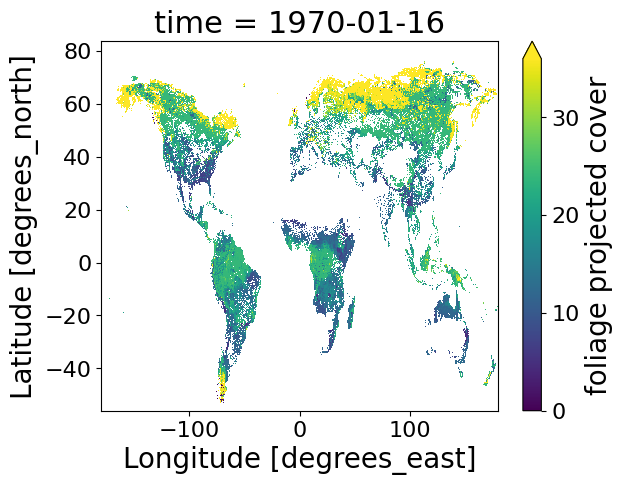

In [84]:
tau_weighted_DM_sum.plot(vmin = 0, vmax = 36)

/scratch-local/77370/ipykernel_3568247/1869296061.py:3: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_continuous = plt.cm.get_cmap(cmap)


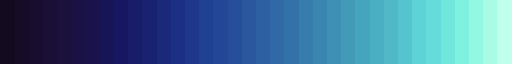

In [12]:
import matplotlib.pyplot as plt
def create_discrete_colormap(cmap, num_colors):
    cmap_continuous = plt.cm.get_cmap(cmap)
    colors_continuous = cmap_continuous(np.linspace(0.03, 1, num_colors))  # Adjusted range, excluding white
    cmap_discrete = plt.matplotlib.colors.ListedColormap(colors_continuous)
    return cmap_discrete

# Example usage:
cmap = create_discrete_colormap(cmaps.blue_bl111, 36)
cmap

/scratch-local/77370/ipykernel_3568247/2341216918.py:3: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_continuous = plt.cm.get_cmap(cmap)


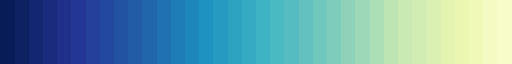

In [13]:
import matplotlib.pyplot as plt
def create_discrete_colormap(cmap, num_colors):
    cmap_continuous = plt.cm.get_cmap(cmap)
    colors_continuous = cmap_continuous(np.linspace(0, 0.95, num_colors))  # Adjusted range, excluding white
    cmap_discrete = plt.matplotlib.colors.ListedColormap(colors_continuous)
    return cmap_discrete

# Example usage:
cmap = create_discrete_colormap("YlGnBu_r", 36)
cmap

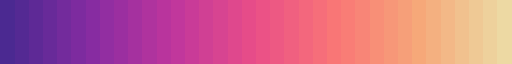

In [91]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap, ListedColormap
import colormaps as cmaps

# Original 7 colors from agsunset
base_colors = cmaps.agsunset.colors

# Create a continuous interpolated colormap
continuous_cmap = LinearSegmentedColormap.from_list(
    "agsunset_interp",
    base_colors
)

# Sample 36 evenly spaced colors
colors_36 = continuous_cmap(np.linspace(0, 1, 36))

# Convert to a discrete matplotlib colormap
cmap_36 = ListedColormap(colors_36)
norm_36 = plt.Normalize(0, 36)
cmap_36

In [ ]:
tau_base_mean = tau_weighted_baseline_sum
tau_DM_mean = tau_weighted_DM_sum

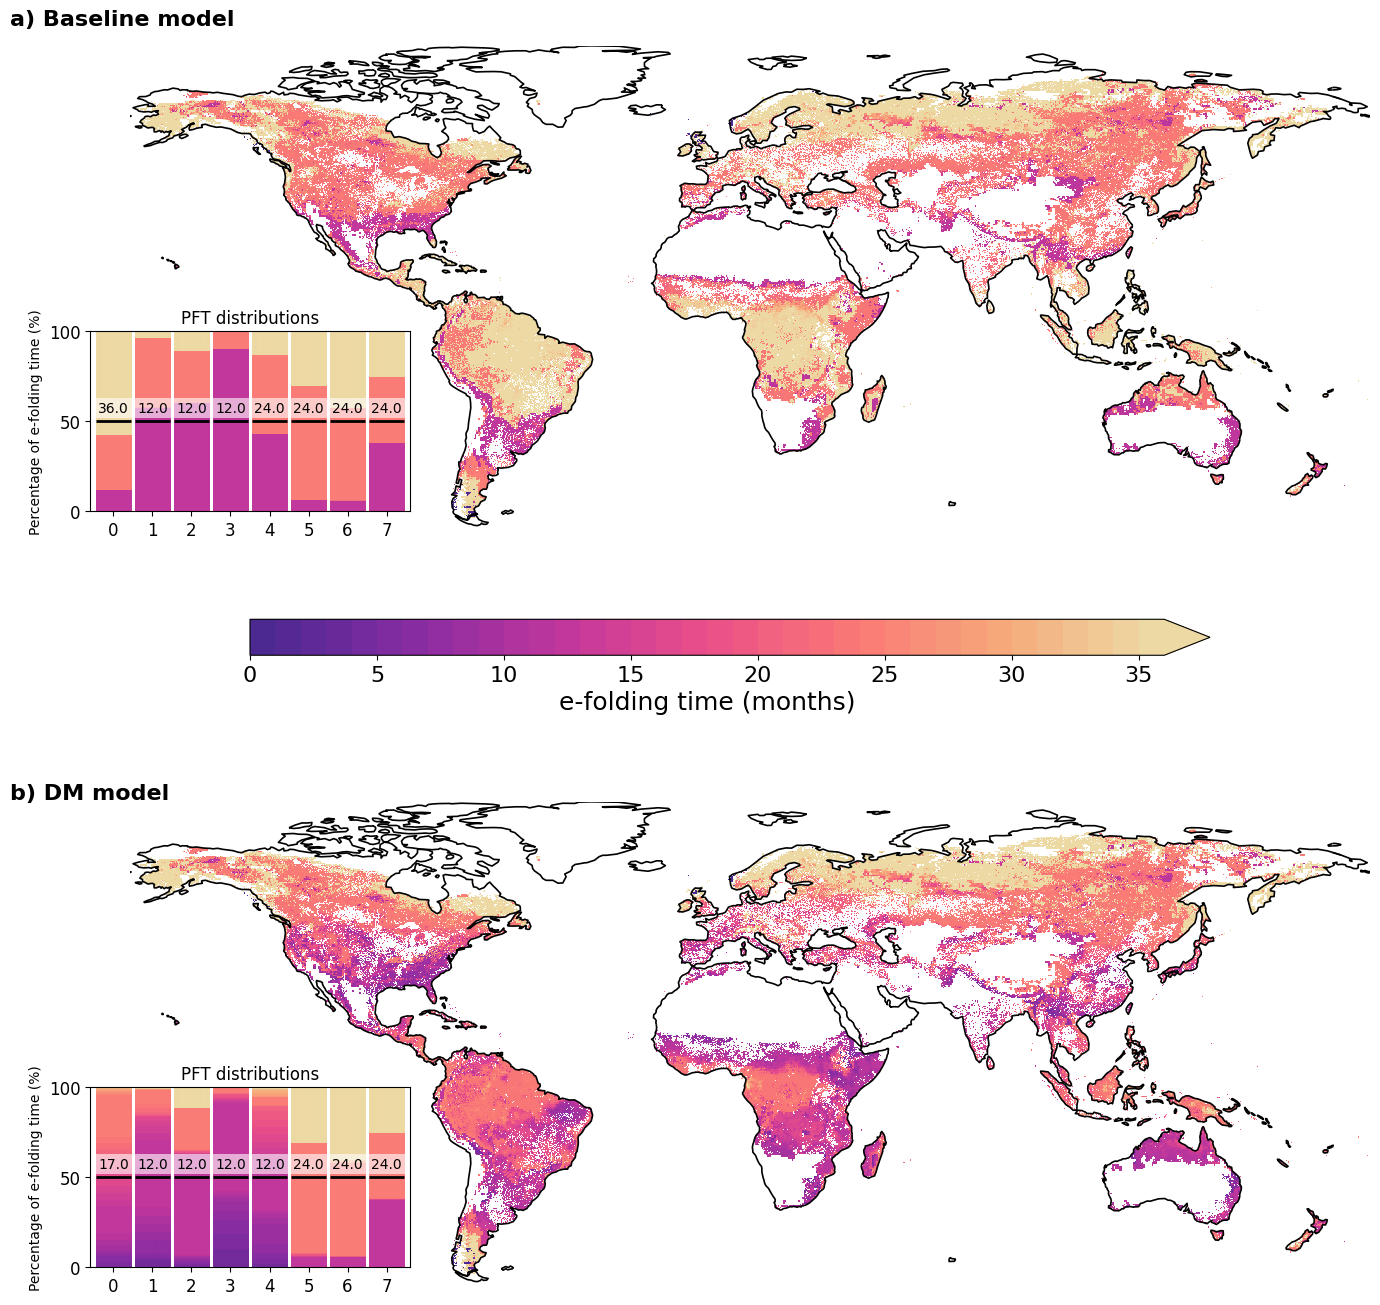

In [ ]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import numpy as np

plt.rcParams.update({
    "font.size": 18,
    "axes.titlesize": 22,
    "axes.labelsize": 20,
    "xtick.labelsize": 16,
    "ytick.labelsize": 16,
})

# -----------------------------
# Clean data
# -----------------------------
tau_base_clean = tau_baseline.where((tau_baseline > 0) & (tau_baseline <= 120))
tau_DM_clean   = tau_DM.where((tau_DM > 0) & (tau_DM <= 120))

pft_names = ['trop.EVG', 'trop.RG', 'temp.NE', 'temp.BE',
              'temp.BS', 'boreal.NE', 'boreal.BS', 'boreal.NS']

pfts = tau_base_clean['pft'].values

norm = plt.Normalize(0, 36)

# -----------------------------
# Figure (maps)
# -----------------------------
fig, axes = plt.subplots(
    2, 1,
    figsize=(16, 18),
    subplot_kw={'projection': ccrs.PlateCarree(central_longitude=11)}
)

tau_base_mean.plot(
    ax=axes[0],
    transform=ccrs.PlateCarree(),
    vmin=0, vmax=36,
    cmap=cmap_36,
    add_colorbar=False
)

im = tau_DM_mean.plot(
    ax=axes[1],
    transform=ccrs.PlateCarree(),
    vmin=0, vmax=36,
    cmap=cmap_36,
    add_colorbar=False
)

for ax in axes:
    ax.coastlines(linewidth=1.2)
    ax.set_title("")
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_frame_on(False)
    ax.set_xlabel("")
    ax.set_ylabel("")

# -----------------------------
# inset helper
# -----------------------------
def plot_strips(ax, data):
    for i, pft in enumerate(pfts):
        vals = data.sel(pft=pft).values.flatten()
        vals = vals[~np.isnan(vals)]

        if len(vals) == 0:
            continue

        vals_sorted = np.sort(vals)

        # convert to percentile coordinates
        y = np.linspace(0, 1, len(vals_sorted))
        strip = vals_sorted[:, None]

        ax.imshow(
            strip,
            aspect='auto',
            cmap=cmap_36,
            norm=norm_36,
            extent=(i - 0.45, i + 0.45, 0, 1),
            origin='lower'
        )

        # median value (statistical)
        median_val = np.median(vals_sorted)

        # FIX: median position in strip is always 0.5 by definition
        y_med = 0.5

        ax.hlines(
            y=y_med,
            xmin=i - 0.45,
            xmax=i + 0.45,
            color='black',
            linewidth=2
        )

        ax.text(
            i,
            y_med + 0.035,
            f"{median_val:.1f}",
            ha='center',
            va='bottom',
            fontsize=10,
            color='black',
            bbox=dict(facecolor='white', alpha=0.6, edgecolor='none', pad=2)
        )

    ax.set_xlim(-0.6, len(pfts) - 0.4)
    ax.set_ylim(0, 1)
    ax.set_yticks([0, 0.5, 1])
    ax.set_yticklabels(["0", "50", "100"], fontsize=12)
    ax.set_xticks(np.arange(len(pfts)))
    ax.set_xticklabels(pfts, fontsize=12)


# -----------------------------
# INSETS
# -----------------------------
inset1 = fig.add_axes([0.1, 0.58, 0.2, 0.1])
plot_strips(inset1, tau_base_clean)
inset1.set_title("PFT distributions", fontsize=12)
inset1.set_ylabel("Percentage of e-folding time (%)", fontsize=10)

inset2 = fig.add_axes([0.1, 0.16, 0.2, 0.1])
plot_strips(inset2, tau_DM_clean)
inset2.set_title("PFT distributions", fontsize=12)
inset2.set_ylabel("Percentage of e-folding time (%)", fontsize=10)

# -----------------------------
# shared colorbar
# -----------------------------
cbar_ax = fig.add_axes([0.2, 0.5, 0.6, 0.02])
cbar = fig.colorbar(im, cax=cbar_ax, orientation='horizontal', extend='max')
cbar.set_label("e-folding time (months)", fontsize=18)
cbar.ax.tick_params(labelsize=16)

# -----------------------------
# panel labels
# -----------------------------
fig.text(0.05, 0.85, "a) Baseline model", fontsize=16, fontweight='bold')
fig.text(0.05, 0.42, "b) DM model", fontsize=16, fontweight='bold')

# -----------------------------
# save + show
# -----------------------------
plt.savefig(
    "/home/druijsch/scripts/2026_06_10_efolding_weighted/tau_maps_with_two_insets_weighted_pink.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

/scratch-local/77370/ipykernel_3568247/4062043638.py:3: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_continuous = plt.cm.get_cmap(cmap)


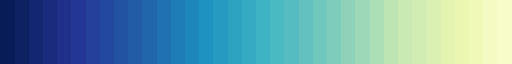

In [81]:
import matplotlib.pyplot as plt
def create_discrete_colormap(cmap, num_colors):
    cmap_continuous = plt.cm.get_cmap(cmap)
    colors_continuous = cmap_continuous(np.linspace(0, 0.95, num_colors))  # Adjusted range, excluding white
    cmap_discrete = plt.matplotlib.colors.ListedColormap(colors_continuous)
    return cmap_discrete

# Example usage:
cmap_36 = create_discrete_colormap("YlGnBu_r", 36)
norm_36 = plt.Normalize(0, 36)
cmap_36

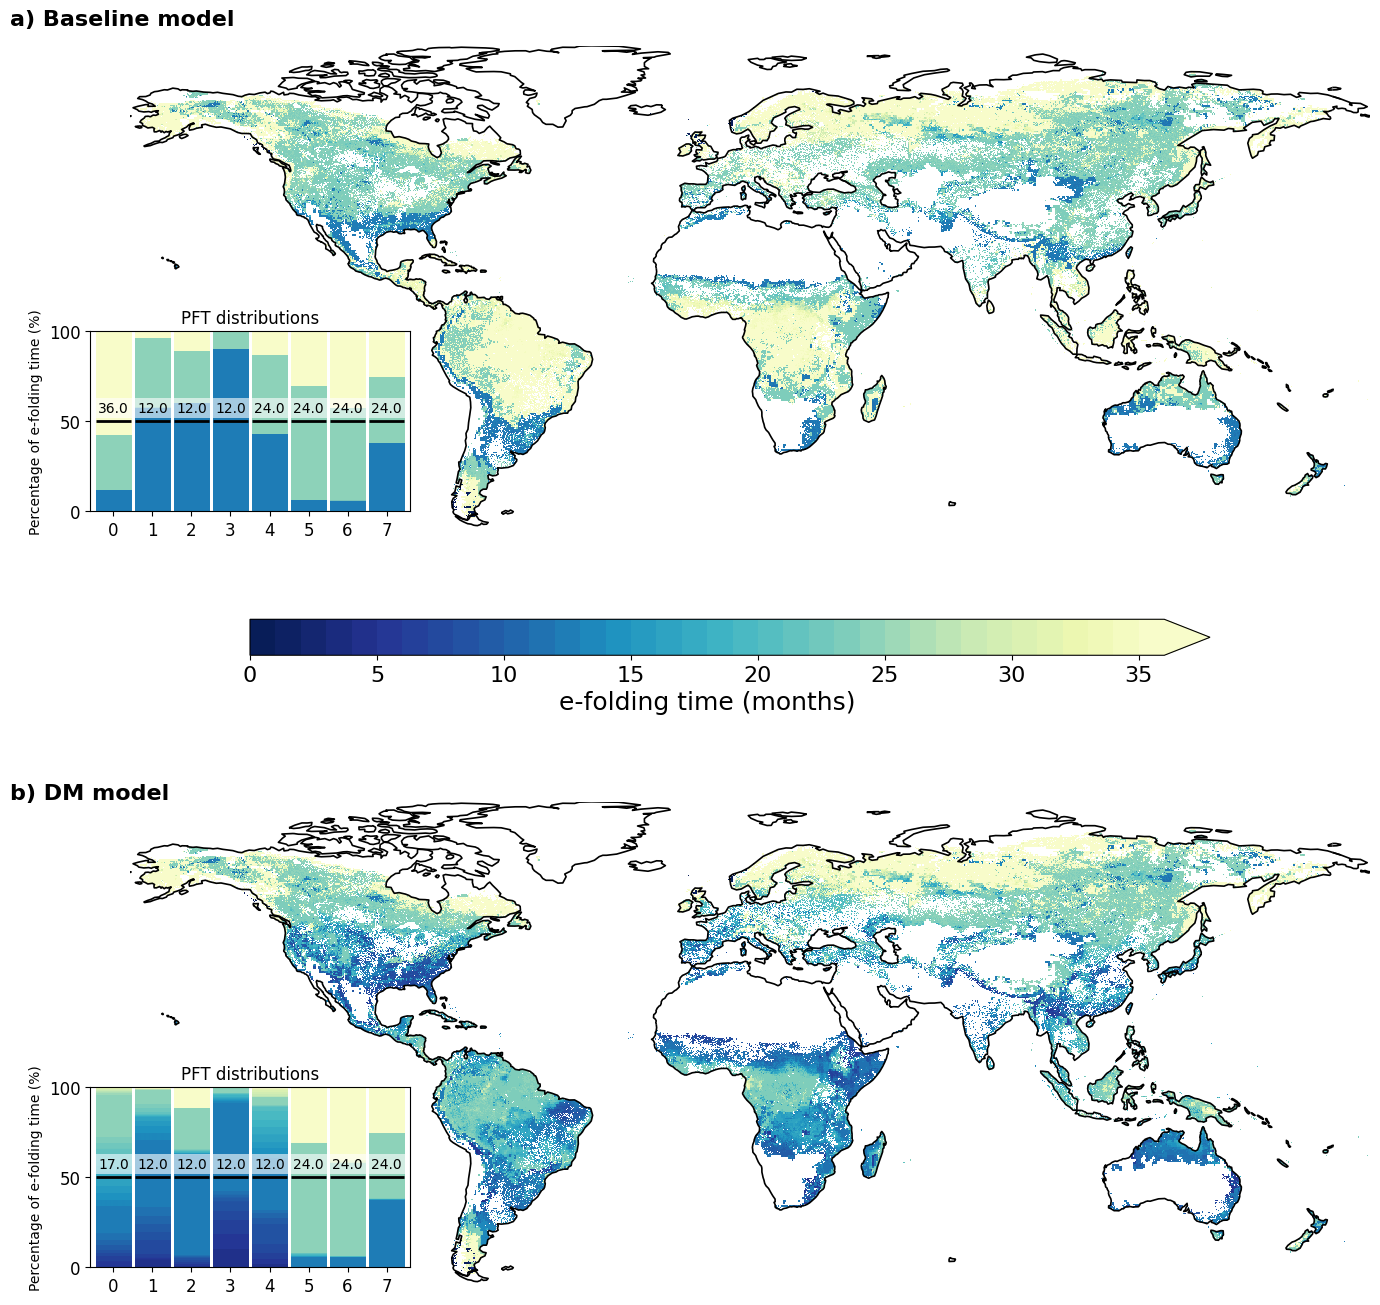

In [85]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import numpy as np

plt.rcParams.update({
    "font.size": 18,
    "axes.titlesize": 22,
    "axes.labelsize": 20,
    "xtick.labelsize": 16,
    "ytick.labelsize": 16,
})

# -----------------------------
# Clean data
# -----------------------------
tau_base_clean = tau_baseline.where((tau_baseline > 0) & (tau_baseline <= 120))
tau_DM_clean   = tau_DM.where((tau_DM > 0) & (tau_DM <= 120))

pft_names = ['trop.EVG', 'trop.RG', 'temp.NE', 'temp.BE',
              'temp.BS', 'boreal.NE', 'boreal.BS', 'boreal.NS']

pfts = tau_base_clean['pft'].values

norm = plt.Normalize(0, 36)

# -----------------------------
# Figure (maps)
# -----------------------------
fig, axes = plt.subplots(
    2, 1,
    figsize=(16, 18),
    subplot_kw={'projection': ccrs.PlateCarree(central_longitude=11)}
)

tau_base_mean.plot(
    ax=axes[0],
    transform=ccrs.PlateCarree(),
    vmin=0, vmax=36,
    cmap=cmap_36,
    add_colorbar=False
)

im = tau_DM_mean.plot(
    ax=axes[1],
    transform=ccrs.PlateCarree(),
    vmin=0, vmax=36,
    cmap=cmap_36,
    add_colorbar=False
)

for ax in axes:
    ax.coastlines(linewidth=1.2)
    ax.set_title("")
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_frame_on(False)
    ax.set_xlabel("")
    ax.set_ylabel("")

# -----------------------------
# inset helper
# -----------------------------
def plot_strips(ax, data):
    for i, pft in enumerate(pfts):
        vals = data.sel(pft=pft).values.flatten()
        vals = vals[~np.isnan(vals)]

        if len(vals) == 0:
            continue

        vals_sorted = np.sort(vals)

        # convert to percentile coordinates
        y = np.linspace(0, 1, len(vals_sorted))
        strip = vals_sorted[:, None]

        ax.imshow(
            strip,
            aspect='auto',
            cmap=cmap_36,
            norm=norm_36,
            extent=(i - 0.45, i + 0.45, 0, 1),
            origin='lower'
        )

        # median value (statistical)
        median_val = np.median(vals_sorted)

        # FIX: median position in strip is always 0.5 by definition
        y_med = 0.5

        ax.hlines(
            y=y_med,
            xmin=i - 0.45,
            xmax=i + 0.45,
            color='black',
            linewidth=2
        )

        ax.text(
            i,
            y_med + 0.035,
            f"{median_val:.1f}",
            ha='center',
            va='bottom',
            fontsize=10,
            color='black',
            bbox=dict(facecolor='white', alpha=0.6, edgecolor='none', pad=2)
        )

    ax.set_xlim(-0.6, len(pfts) - 0.4)
    ax.set_ylim(0, 1)
    ax.set_yticks([0, 0.5, 1])
    ax.set_yticklabels(["0", "50", "100"], fontsize=12)
    ax.set_xticks(np.arange(len(pfts)))
    ax.set_xticklabels(pfts, fontsize=12)


# -----------------------------
# INSETS
# -----------------------------
inset1 = fig.add_axes([0.1, 0.58, 0.2, 0.1])
plot_strips(inset1, tau_base_clean)
inset1.set_title("PFT distributions", fontsize=12)
inset1.set_ylabel("Percentage of e-folding time (%)", fontsize=10)

inset2 = fig.add_axes([0.1, 0.16, 0.2, 0.1])
plot_strips(inset2, tau_DM_clean)
inset2.set_title("PFT distributions", fontsize=12)
inset2.set_ylabel("Percentage of e-folding time (%)", fontsize=10)

# -----------------------------
# shared colorbar
# -----------------------------
cbar_ax = fig.add_axes([0.2, 0.5, 0.6, 0.02])
cbar = fig.colorbar(im, cax=cbar_ax, orientation='horizontal', extend='max')
cbar.set_label("e-folding time (months)", fontsize=18)
cbar.ax.tick_params(labelsize=16)

# -----------------------------
# panel labels
# -----------------------------
fig.text(0.05, 0.85, "a) Baseline model", fontsize=16, fontweight='bold')
fig.text(0.05, 0.42, "b) DM model", fontsize=16, fontweight='bold')

# -----------------------------
# save + show
# -----------------------------
plt.savefig(
    "/home/druijsch/scripts/2026_06_10_efolding_weighted/tau_maps_with_two_insets_weighted_blue.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

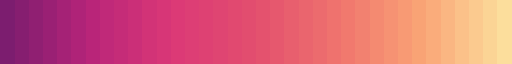

In [94]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap, ListedColormap
import colormaps as cmaps

# Original 7 colors from sunsetdark
base_colors = cmaps.sunsetdark_r.colors

# Create a continuous interpolated colormap
continuous_cmap = LinearSegmentedColormap.from_list(
    "sunsetdark_interp",
    base_colors
)

# Sample 36 evenly spaced colors
colors_36 = continuous_cmap(np.linspace(0, 1, 36))

# Convert to a discrete matplotlib colormap
cmap_36 = ListedColormap(colors_36)
norm_36 = plt.Normalize(0, 36)
cmap_36

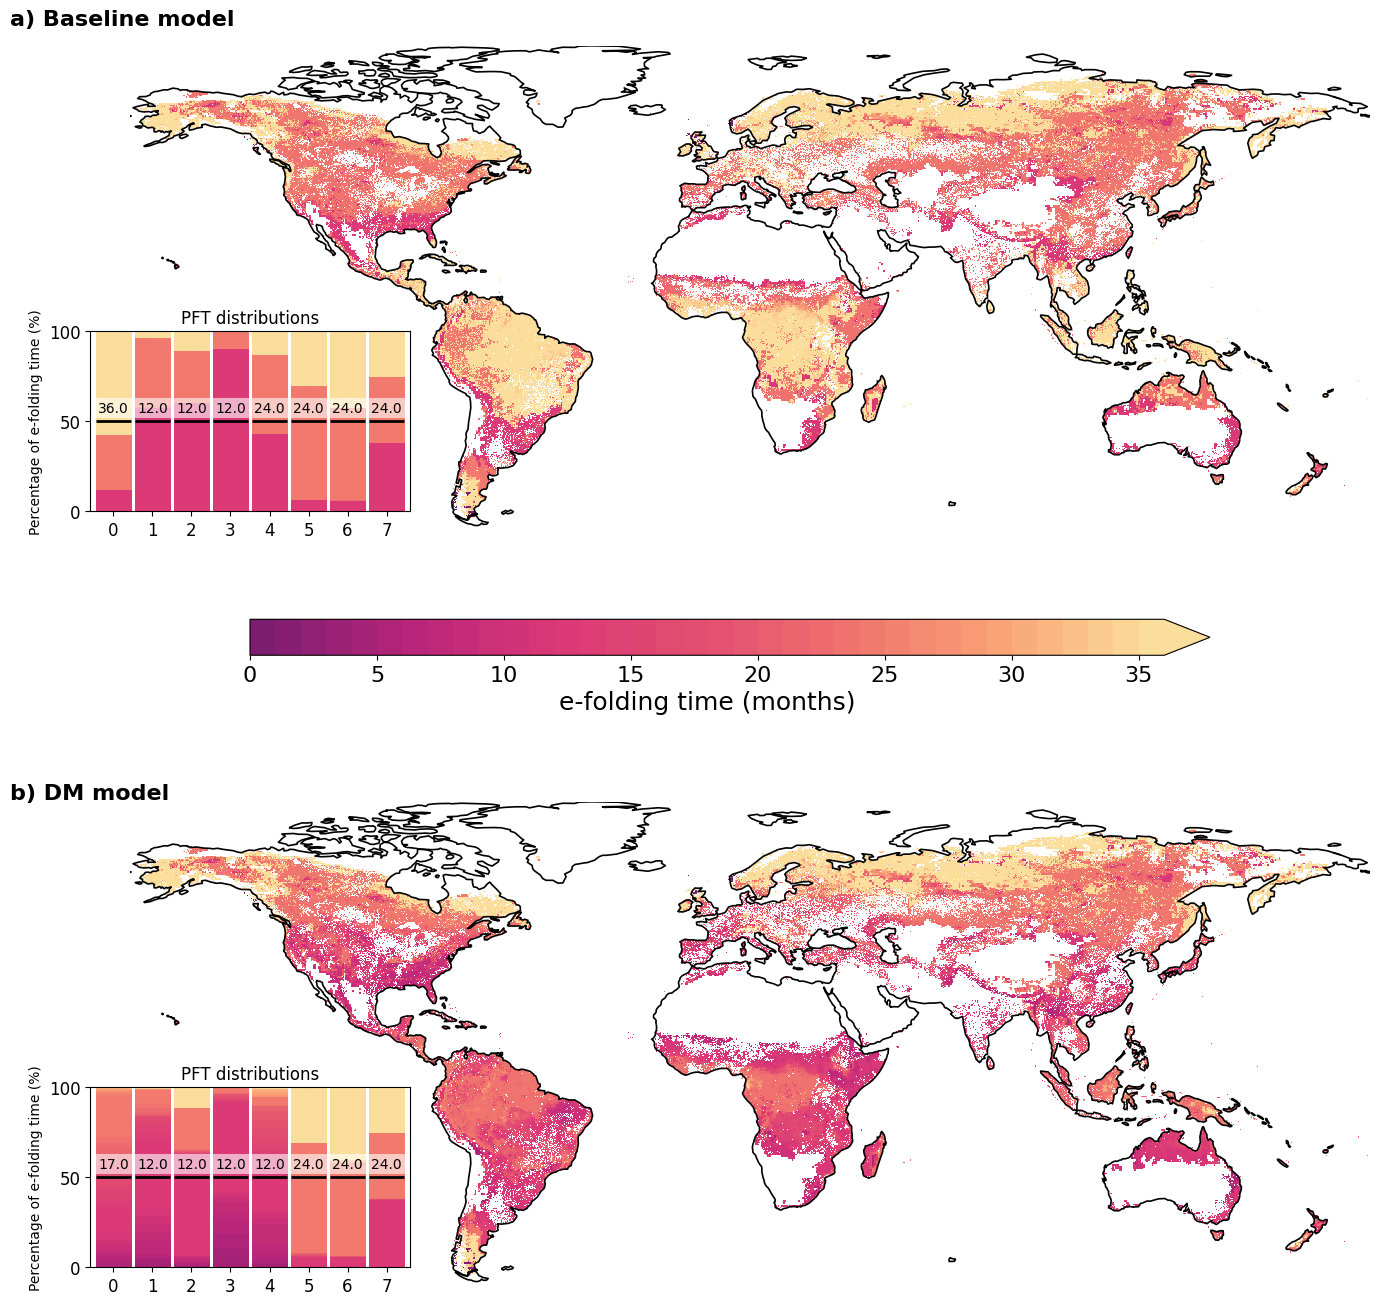

In [95]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import numpy as np

plt.rcParams.update({
    "font.size": 18,
    "axes.titlesize": 22,
    "axes.labelsize": 20,
    "xtick.labelsize": 16,
    "ytick.labelsize": 16,
})

# -----------------------------
# Clean data
# -----------------------------
tau_base_clean = tau_baseline.where((tau_baseline > 0) & (tau_baseline <= 120))
tau_DM_clean   = tau_DM.where((tau_DM > 0) & (tau_DM <= 120))

pft_names = ['trop.EVG', 'trop.RG', 'temp.NE', 'temp.BE',
              'temp.BS', 'boreal.NE', 'boreal.BS', 'boreal.NS']

pfts = tau_base_clean['pft'].values

norm = plt.Normalize(0, 36)

# -----------------------------
# Figure (maps)
# -----------------------------
fig, axes = plt.subplots(
    2, 1,
    figsize=(16, 18),
    subplot_kw={'projection': ccrs.PlateCarree(central_longitude=11)}
)

tau_base_mean.plot(
    ax=axes[0],
    transform=ccrs.PlateCarree(),
    vmin=0, vmax=36,
    cmap=cmap_36,
    add_colorbar=False
)

im = tau_DM_mean.plot(
    ax=axes[1],
    transform=ccrs.PlateCarree(),
    vmin=0, vmax=36,
    cmap=cmap_36,
    add_colorbar=False
)

for ax in axes:
    ax.coastlines(linewidth=1.2)
    ax.set_title("")
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_frame_on(False)
    ax.set_xlabel("")
    ax.set_ylabel("")

# -----------------------------
# inset helper
# -----------------------------
def plot_strips(ax, data):
    for i, pft in enumerate(pfts):
        vals = data.sel(pft=pft).values.flatten()
        vals = vals[~np.isnan(vals)]

        if len(vals) == 0:
            continue

        vals_sorted = np.sort(vals)

        # convert to percentile coordinates
        y = np.linspace(0, 1, len(vals_sorted))
        strip = vals_sorted[:, None]

        ax.imshow(
            strip,
            aspect='auto',
            cmap=cmap_36,
            norm=norm_36,
            extent=(i - 0.45, i + 0.45, 0, 1),
            origin='lower'
        )

        # median value (statistical)
        median_val = np.median(vals_sorted)

        # FIX: median position in strip is always 0.5 by definition
        y_med = 0.5

        ax.hlines(
            y=y_med,
            xmin=i - 0.45,
            xmax=i + 0.45,
            color='black',
            linewidth=2
        )

        ax.text(
            i,
            y_med + 0.035,
            f"{median_val:.1f}",
            ha='center',
            va='bottom',
            fontsize=10,
            color='black',
            bbox=dict(facecolor='white', alpha=0.6, edgecolor='none', pad=2)
        )

    ax.set_xlim(-0.6, len(pfts) - 0.4)
    ax.set_ylim(0, 1)
    ax.set_yticks([0, 0.5, 1])
    ax.set_yticklabels(["0", "50", "100"], fontsize=12)
    ax.set_xticks(np.arange(len(pfts)))
    ax.set_xticklabels(pfts, fontsize=12)


# -----------------------------
# INSETS
# -----------------------------
inset1 = fig.add_axes([0.1, 0.58, 0.2, 0.1])
plot_strips(inset1, tau_base_clean)
inset1.set_title("PFT distributions", fontsize=12)
inset1.set_ylabel("Percentage of e-folding time (%)", fontsize=10)

inset2 = fig.add_axes([0.1, 0.16, 0.2, 0.1])
plot_strips(inset2, tau_DM_clean)
inset2.set_title("PFT distributions", fontsize=12)
inset2.set_ylabel("Percentage of e-folding time (%)", fontsize=10)

# -----------------------------
# shared colorbar
# -----------------------------
cbar_ax = fig.add_axes([0.2, 0.5, 0.6, 0.02])
cbar = fig.colorbar(im, cax=cbar_ax, orientation='horizontal', extend='max')
cbar.set_label("e-folding time (months)", fontsize=18)
cbar.ax.tick_params(labelsize=16)

# -----------------------------
# panel labels
# -----------------------------
fig.text(0.05, 0.85, "a) Baseline model", fontsize=16, fontweight='bold')
fig.text(0.05, 0.42, "b) DM model", fontsize=16, fontweight='bold')

# -----------------------------
# save + show
# -----------------------------
plt.savefig(
    "/home/druijsch/scripts/2026_06_10_efolding_weighted/tau_maps_with_two_insets_weighted_pink2.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

/scratch-local/77370/ipykernel_3568247/3328264464.py:3: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_continuous = plt.cm.get_cmap(cmap)


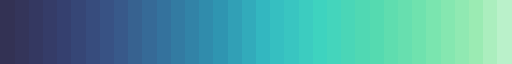

In [100]:
import matplotlib.pyplot as plt
def create_discrete_colormap(cmap, num_colors):
    cmap_continuous = plt.cm.get_cmap(cmap)
    colors_continuous = cmap_continuous(np.linspace(0, 0.95, num_colors))  # Adjusted range, excluding white
    cmap_discrete = plt.matplotlib.colors.ListedColormap(colors_continuous)
    return cmap_discrete

# Example usage:
cmap_36 = create_discrete_colormap(cmaps.bl_11_r, 36)
norm_36 = plt.Normalize(0, 36)
cmap_36

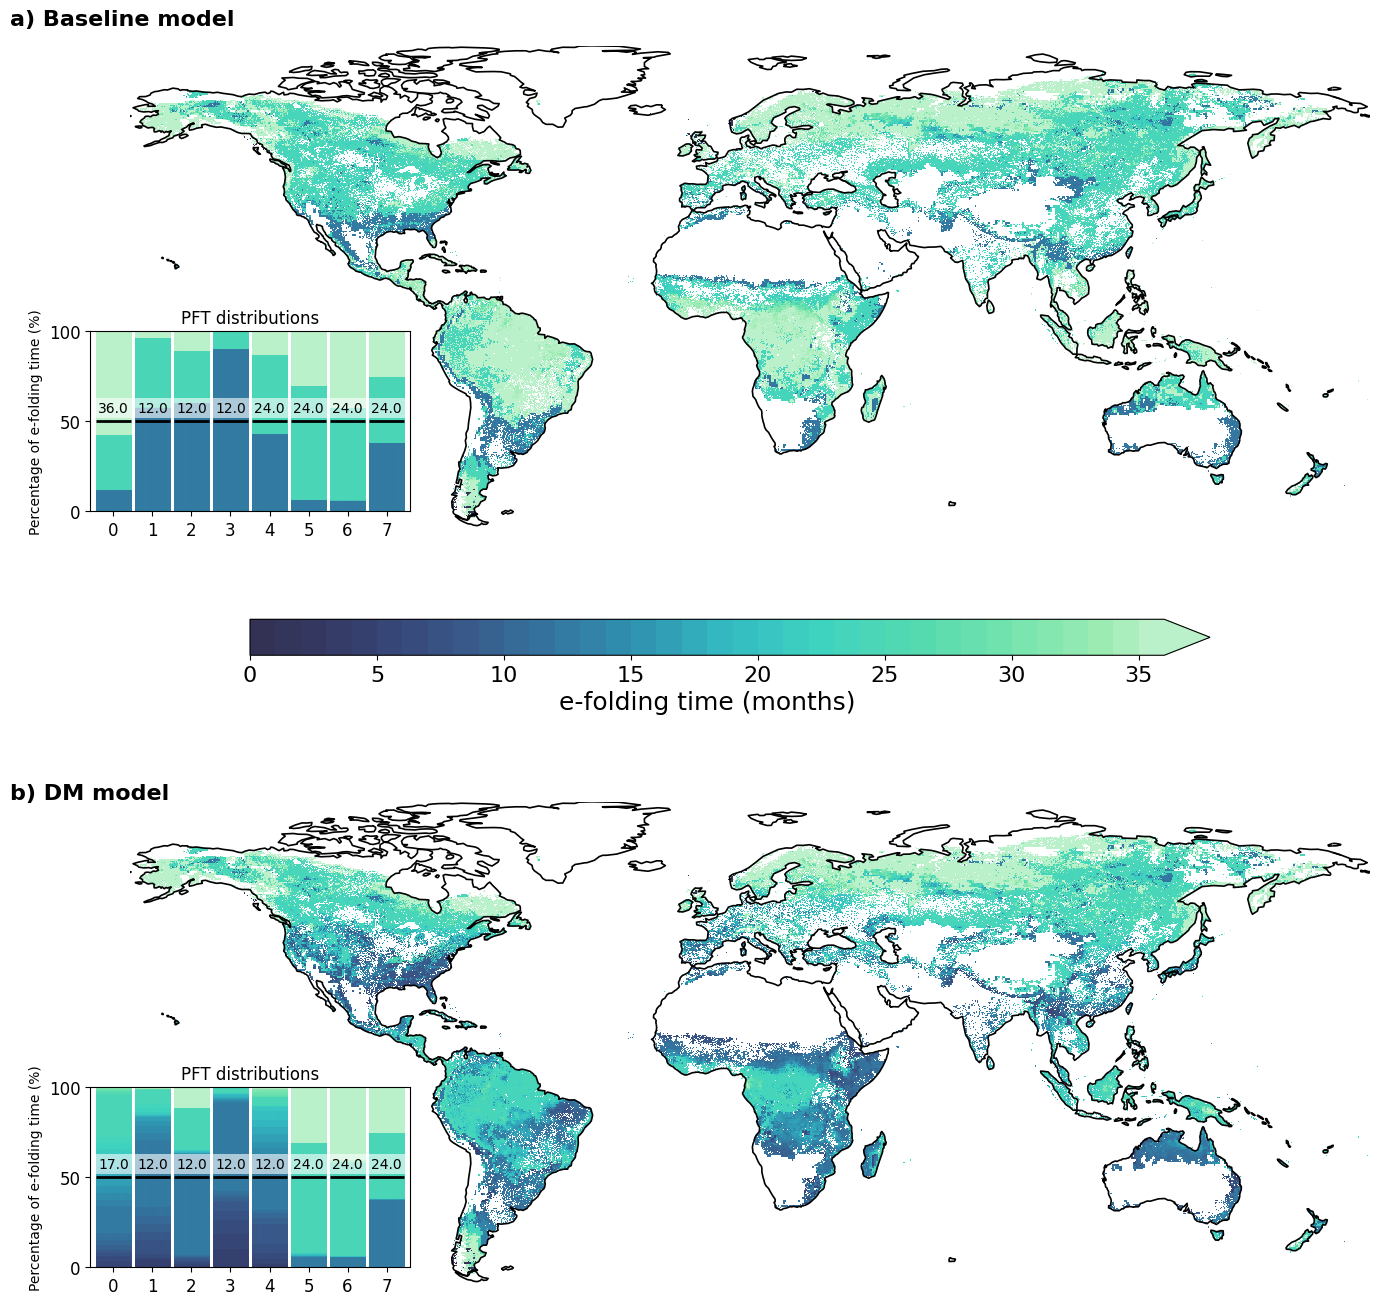

In [101]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import numpy as np

plt.rcParams.update({
    "font.size": 18,
    "axes.titlesize": 22,
    "axes.labelsize": 20,
    "xtick.labelsize": 16,
    "ytick.labelsize": 16,
})

# -----------------------------
# Clean data
# -----------------------------
tau_base_clean = tau_baseline.where((tau_baseline > 0) & (tau_baseline <= 120))
tau_DM_clean   = tau_DM.where((tau_DM > 0) & (tau_DM <= 120))

pft_names = ['trop.EVG', 'trop.RG', 'temp.NE', 'temp.BE',
              'temp.BS', 'boreal.NE', 'boreal.BS', 'boreal.NS']

pfts = tau_base_clean['pft'].values

norm = plt.Normalize(0, 36)

# -----------------------------
# Figure (maps)
# -----------------------------
fig, axes = plt.subplots(
    2, 1,
    figsize=(16, 18),
    subplot_kw={'projection': ccrs.PlateCarree(central_longitude=11)}
)

tau_base_mean.plot(
    ax=axes[0],
    transform=ccrs.PlateCarree(),
    vmin=0, vmax=36,
    cmap=cmap_36,
    add_colorbar=False
)

im = tau_DM_mean.plot(
    ax=axes[1],
    transform=ccrs.PlateCarree(),
    vmin=0, vmax=36,
    cmap=cmap_36,
    add_colorbar=False
)

for ax in axes:
    ax.coastlines(linewidth=1.2)
    ax.set_title("")
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_frame_on(False)
    ax.set_xlabel("")
    ax.set_ylabel("")

# -----------------------------
# inset helper
# -----------------------------
def plot_strips(ax, data):
    for i, pft in enumerate(pfts):
        vals = data.sel(pft=pft).values.flatten()
        vals = vals[~np.isnan(vals)]

        if len(vals) == 0:
            continue

        vals_sorted = np.sort(vals)

        # convert to percentile coordinates
        y = np.linspace(0, 1, len(vals_sorted))
        strip = vals_sorted[:, None]

        ax.imshow(
            strip,
            aspect='auto',
            cmap=cmap_36,
            norm=norm_36,
            extent=(i - 0.45, i + 0.45, 0, 1),
            origin='lower'
        )

        # median value (statistical)
        median_val = np.median(vals_sorted)

        # FIX: median position in strip is always 0.5 by definition
        y_med = 0.5

        ax.hlines(
            y=y_med,
            xmin=i - 0.45,
            xmax=i + 0.45,
            color='black',
            linewidth=2
        )

        ax.text(
            i,
            y_med + 0.035,
            f"{median_val:.1f}",
            ha='center',
            va='bottom',
            fontsize=10,
            color='black',
            bbox=dict(facecolor='white', alpha=0.6, edgecolor='none', pad=2)
        )

    ax.set_xlim(-0.6, len(pfts) - 0.4)
    ax.set_ylim(0, 1)
    ax.set_yticks([0, 0.5, 1])
    ax.set_yticklabels(["0", "50", "100"], fontsize=12)
    ax.set_xticks(np.arange(len(pfts)))
    ax.set_xticklabels(pfts, fontsize=12)


# -----------------------------
# INSETS
# -----------------------------
inset1 = fig.add_axes([0.1, 0.58, 0.2, 0.1])
plot_strips(inset1, tau_base_clean)
inset1.set_title("PFT distributions", fontsize=12)
inset1.set_ylabel("Percentage of e-folding time (%)", fontsize=10)

inset2 = fig.add_axes([0.1, 0.16, 0.2, 0.1])
plot_strips(inset2, tau_DM_clean)
inset2.set_title("PFT distributions", fontsize=12)
inset2.set_ylabel("Percentage of e-folding time (%)", fontsize=10)

# -----------------------------
# shared colorbar
# -----------------------------
cbar_ax = fig.add_axes([0.2, 0.5, 0.6, 0.02])
cbar = fig.colorbar(im, cax=cbar_ax, orientation='horizontal', extend='max')
cbar.set_label("e-folding time (months)", fontsize=18)
cbar.ax.tick_params(labelsize=16)

# -----------------------------
# panel labels
# -----------------------------
fig.text(0.05, 0.85, "a) Baseline model", fontsize=16, fontweight='bold')
fig.text(0.05, 0.42, "b) DM model", fontsize=16, fontweight='bold')

# -----------------------------
# save + show
# -----------------------------
plt.savefig(
    "/home/druijsch/scripts/2026_06_10_efolding_weighted/tau_maps_with_two_insets_weighted_blue2.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()